## Task 2: Exploratory Data Analysis (EDA)

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [9]:
df = pd.read_csv(r'C:\Users\akshi\OneDrive\Desktop\Data Analysis\Data Analysis\Saiket Systems\Data\Telco_Customer_Churn_Dataset .csv')

print("Dataset Loaded Successfully\n")

Dataset Loaded Successfully



In [10]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nSummary Statistics:\n")
print(df.describe())

Dataset Shape: (7043, 21)

Column Names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Summary Statistics:

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


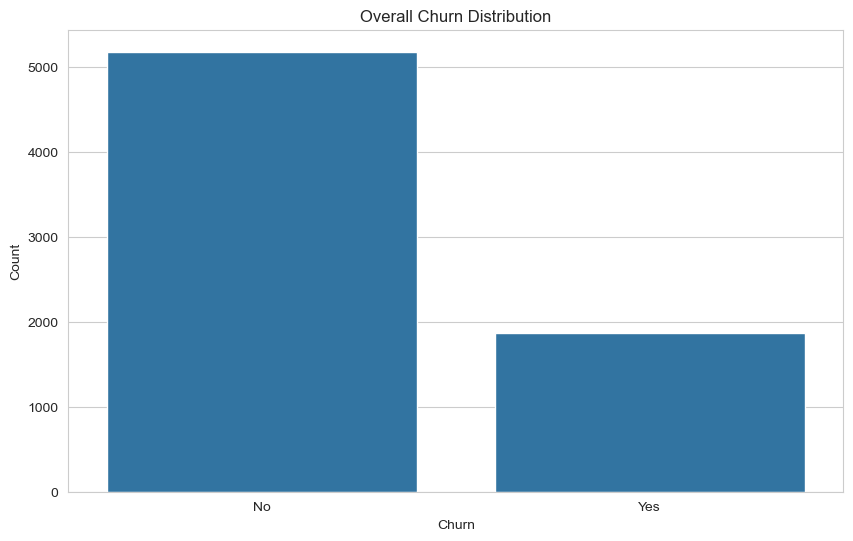

In [11]:
plt.figure()
sns.countplot(x='Churn', data=df)
plt.title('Overall Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

In [17]:
churn_rate = df['Churn'].value_counts(normalize=True)['Yes'] * 100
print(f"\n Overall Churn Rate: {churn_rate:.2f}%")


 Overall Churn Rate: 26.54%


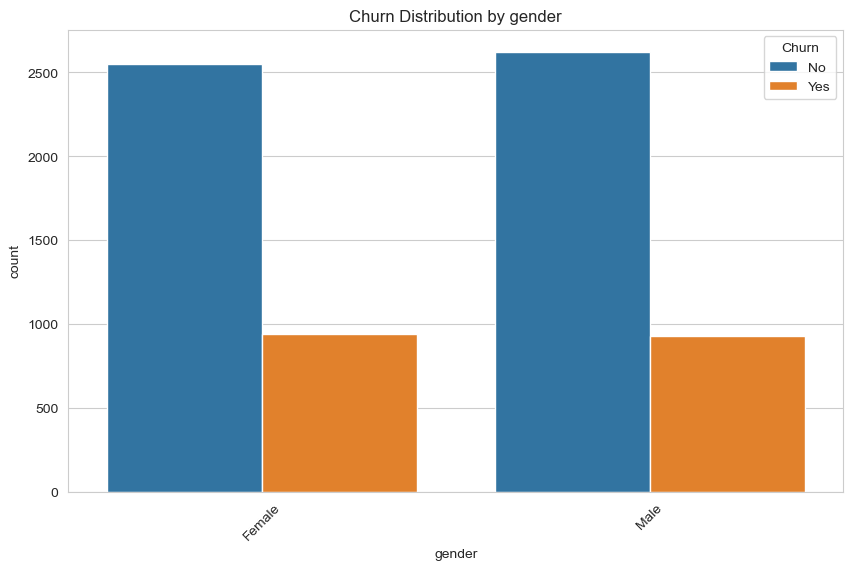

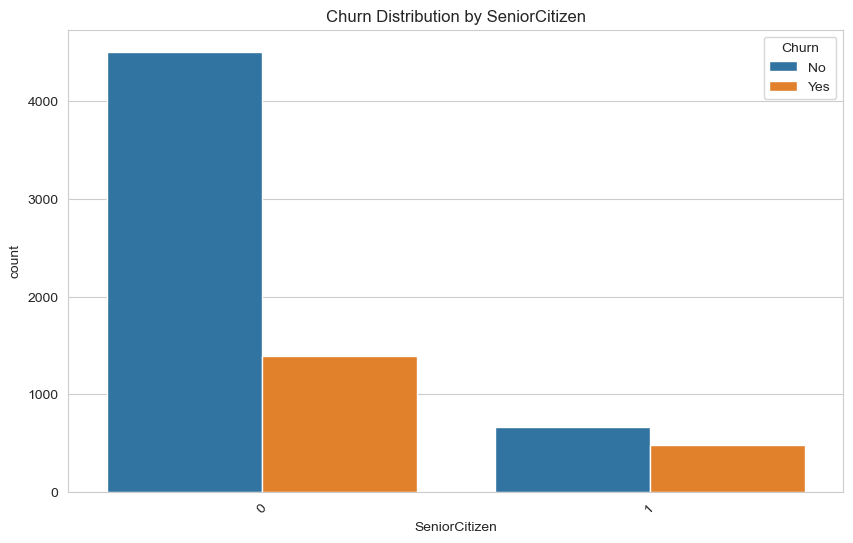

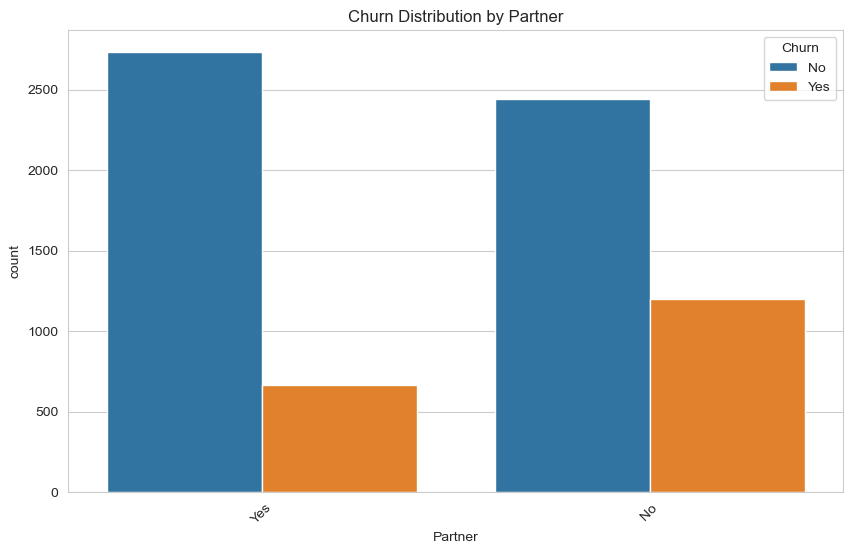

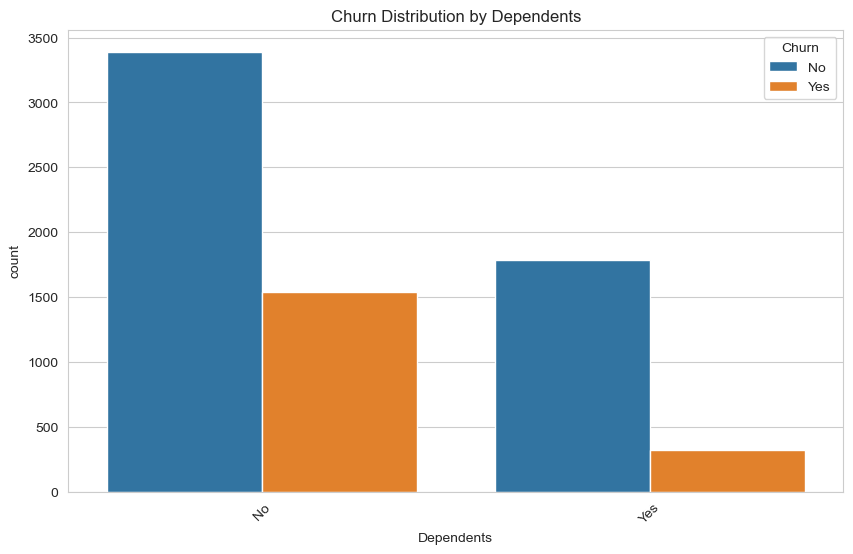

In [18]:
def plot_demographic(feature):
    plt.figure()
    sns.countplot(x=feature, hue='Churn', data=df)
    plt.title(f'Churn Distribution by {feature}')
    plt.xticks(rotation=45)
    plt.show()
for col in ['gender', 'SeniorCitizen', 'Partner', 'Dependents']:
    plot_demographic(col)

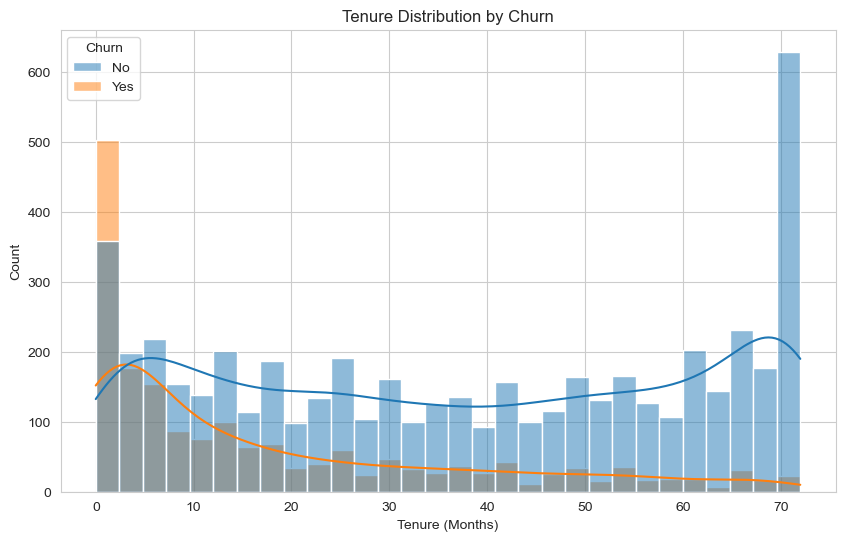

In [19]:
plt.figure()
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.show()

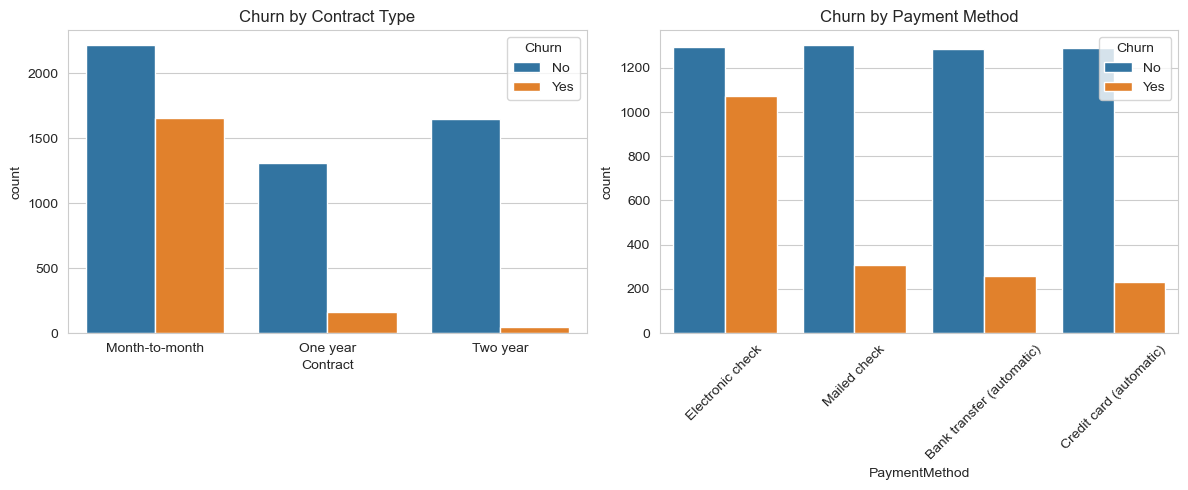

In [20]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.subplot(1, 2, 2)
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title('Churn by Payment Method')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
print("\n Churn Rate by Contract Type:\n")
print(contract_churn)


 Churn Rate by Contract Type:

Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887305  0.112695
Two year        0.971681  0.028319


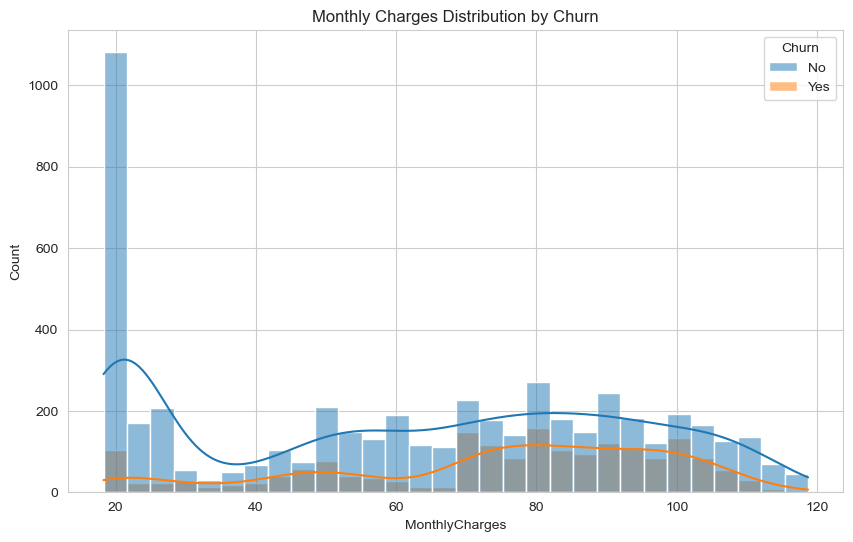

In [22]:
plt.figure()
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True)
plt.title('Monthly Charges Distribution by Churn')
plt.show()

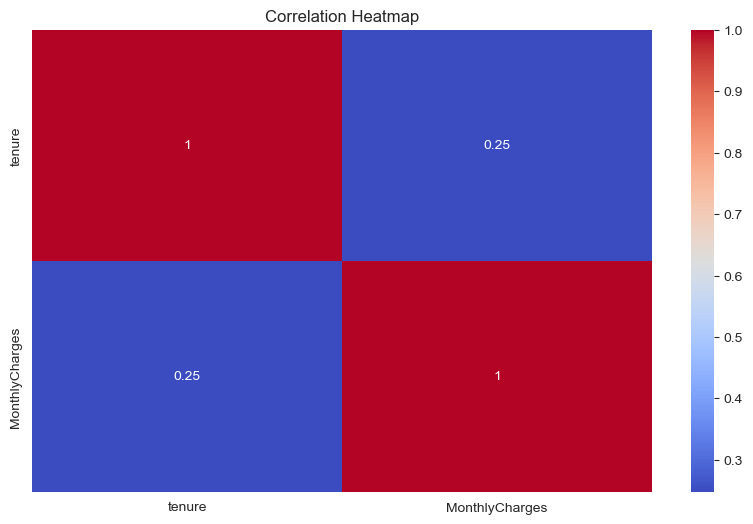

In [23]:
df_numeric = df[['tenure', 'MonthlyCharges']]
plt.figure()
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [24]:
print("\n Key Observations:")
print("- Month-to-month contracts show higher churn")
print("- Customers with shorter tenure churn more")
print("- Higher monthly charges are linked to higher churn")


 Key Observations:
- Month-to-month contracts show higher churn
- Customers with shorter tenure churn more
- Higher monthly charges are linked to higher churn
